# QE-ARL — Reproducibility Notebook

**Quantum-Enhanced Agentic Reinforcement Learning for Max-Cut**


### Teacher requirements implemented
1. **Parameter-matched nonlinear classical baseline:** an 8-parameter nonlinear MLP (`MLP8-ARL`) matched exactly to the 8 VQC parameters, plus a 20-parameter nonlinear MLP (`MLP20-ARL`) matched to the original 20-parameter affine controller. All use the same four state features and RL/search protocol.
2. **More training seeds:** five seeds `{11, 23, 37, 41, 53}`.
3. **Scale:** `n = 16, 20, 24` using a high-budget multi-start iterated local-search feasible reference, not exhaustive enumeration.
4. **Gset:** six genuine Stanford Gset instances (`G1, G6, G11, G14, G18, G22`), with node/edge-count validation and SHA-256 source hashes.
5. **Weighted Max-Cut:** positive integer-weighted Erdős–Rényi stress tests plus signed-weight `±1` Gset instances.
6. **Shot-noise robustness:** VQC inference with **1,000** and **8,000** measurement shots, paired against exact statevector inference.
7. **QAOA:** `p=2` statevector QAOA on all 72 exact-verification graphs, with three optimizer restarts. `p=2` matches the number of QE-ARL trainable variational rotation layers; this is explicitly **not** claimed to match physical gate count or qubit count.
8. **SPSA validation:** training-style single-direction SPSA is compared with exact parameter-shift gradients on held-out policy states; an 8-direction averaged SPSA diagnostic is also reported.

### Important scientific wording
- Small `n=8,10,12` graphs use **exact** Max-Cut optima.
- `n=16,20,24` results are ratios to a **feasible heuristic reference**, not certified approximation ratios.
- Gset denominators are **published best-known/target values**, not proven optima.
- Finite-shot simulation models sampling noise only; it is **not** a hardware/noise/transpilation experiment.
- No quantum-advantage or quantum-speedup claim is made.

Run **Runtime → Run all** in a fresh Colab session. At the end, download `artifacts/QE_ARL_complete_revision_results.zip` and send it back for the conference-paper update.


In [1]:
from pathlib import Path
import time, json, math, hashlib, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

OUT = Path('artifacts')
OUT.mkdir(exist_ok=True)
(OUT/'gset_raw').mkdir(exist_ok=True)
np.set_printoptions(precision=5, suppress=True)

print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
try:
    import scipy
    print('SciPy:', scipy.__version__)
except Exception:
    pass
print('Artifact directory:', OUT.resolve())

NumPy: 2.1.3
pandas: 2.2.3
SciPy: 1.16.3
Artifact directory: /content/artifacts


## Verified methodological references used by this revision

These are real sources and are included here so that the experimental choices can be checked independently.

- **Quantum-optimization benchmarking caution:** A. Abbas *et al.*, “Challenges and opportunities in quantum optimization,” *Nature Reviews Physics*, 6, 718–735 (2024). DOI: **10.1038/s42254-024-00770-9**.
- **QAOA benchmarking:** M. Willsch *et al.*, “Benchmarking the quantum approximate optimization algorithm,” *Quantum Information Processing*, 19, 197 (2020). DOI: **10.1007/s11128-020-02692-8**.
- **QAOA review:** K. Blekos *et al.*, “A review on Quantum Approximate Optimization Algorithm and its variants,” *Physics Reports*, 1068, 1–66 (2024). DOI: **10.1016/j.physrep.2024.03.002**.
- **SPSA:** J. C. Spall, “Multivariate stochastic approximation using a simultaneous perturbation gradient approximation,” *IEEE Transactions on Automatic Control*, 37(3), 332–341 (1992). DOI: **10.1109/9.119632**.
- **Parameter-shift gradients:** M. Schuld, V. Bergholm, C. Gogolin, J. Izaac, and N. Killoran, “Evaluating analytic gradients on quantum hardware,” *Physical Review A*, 99, 032331 (2019). DOI: **10.1103/PhysRevA.99.032331**.
- **Original Gset data source:** Y. Ye, Gset benchmark archive, Stanford University (2003): `https://web.stanford.edu/~yyye/yyye/Gset/`.
- **Current Gset targets used below:** N. Onizawa and T. Hanyu, “A unified performance–cost landscape of parallel p-bit Ising machines based on update dynamics,” *Scientific Reports*, 16, 16643 (2026). DOI: **10.1038/s41598-026-47285-0**. Its Table 4 reports the six benchmark targets used here.

## 1. Core unweighted Max-Cut environment and policies

In [2]:
SEED = 7
rng = np.random.default_rng(SEED)

# ---------- Unweighted graph / Max-Cut ----------
def make_graph(n=10, p=0.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    A = (rng.random((n,n)) < p).astype(np.int8)
    A = np.triu(A,1); A = A + A.T
    if A.sum() == 0:
        A[0,1] = A[1,0] = 1
    return A

def make_weighted_graph(n=20, p=0.5, rng=None, low=1, high=10):
    """Positive integer-weighted ER graph for the weighted Max-Cut stress test."""
    rng = np.random.default_rng() if rng is None else rng
    M = np.triu(rng.random((n,n)) < p, 1)
    R = rng.integers(low, high+1, size=(n,n))
    U = (M * R).astype(np.int32)
    W = U + U.T
    if W.sum() == 0:
        W[0,1] = W[1,0] = 1
    return W

def cut_value(A, x):
    return int(np.sum(np.triu(A,1) * (x[:,None] != x[None,:])))

def exact_maxcut(A):
    n = len(A); best = -10**18; bx = None
    # Complement symmetry: fix x_0 = 0.
    for mask in range(1 << (n-1)):
        x = np.zeros(n, dtype=np.int8)
        for j in range(1,n):
            x[j] = (mask >> (j-1)) & 1
        v = cut_value(A,x)
        if v > best:
            best = v; bx = x.copy()
    return best, bx

def single_flip_gains(A, x):
    same = (x[:,None] == x[None,:])
    diff = ~same
    return np.sum(A*same,axis=1) - np.sum(A*diff,axis=1)

def apply_action(A, x, action, rng):
    x = x.copy(); gains = single_flip_gains(A,x); n = len(x)
    if action == 0:  # best one-bit flip
        x[int(np.argmax(gains))] ^= 1
    elif action == 1:  # gain-biased stochastic flip
        z = gains - gains.max()
        w = np.exp(z/1.5); w /= w.sum()
        x[int(rng.choice(n,p=w))] ^= 1
    elif action == 2:  # pair flip from four highest-gain vertices
        idx = np.argsort(gains)[-min(4,n):]
        if len(idx) >= 2:
            x[rng.choice(idx,size=2,replace=False)] ^= 1
        else:
            x[int(idx[-1])] ^= 1
    elif action == 3:  # structured perturbation
        k = max(1, int(np.ceil(0.2*n)))
        x[rng.choice(n,size=k,replace=False)] ^= 1
    else:
        raise ValueError(action)
    return x

def features(A, x, best_val, stall, max_steps, step=0):
    # For nonnegative weights, m is the total edge weight. On unweighted graphs it is |E|.
    m = max(1, int(A.sum()//2))
    cur = cut_value(A,x); gains = single_flip_gains(A,x)
    maxdeg = max(1, int(np.abs(A).sum(axis=1).max()))
    return np.array([
        np.clip(2*cur/m - 1, -1, 1),
        np.clip(2*best_val/m - 1, -1, 1),
        np.clip(2*stall/max_steps - 1, -1, 1),
        np.clip(np.mean(gains)/maxdeg, -1, 1),
    ], dtype=float)

# ---------- 4-qubit VQC ----------
NQ = 4; DIM = 1 << NQ

def ry(t):
    c=np.cos(t/2); s=np.sin(t/2)
    return np.array([[c,-s],[s,c]],dtype=np.complex128)

def apply_1q(state,U,q,nq=NQ):
    st=state.reshape([2]*nq)
    st=np.moveaxis(st,q,0)
    sh=st.shape; st=st.reshape(2,-1)
    st=(U@st).reshape(sh)
    st=np.moveaxis(st,0,q)
    return st.reshape(-1)

# Precomputed permutations make the exact same CNOT algebra faster and easier to audit.
PERM = {}
for c in range(NQ):
    for t in range(NQ):
        if c != t:
            PERM[(c,t)] = np.array([
                j ^ ((1 << (NQ-1-t)) if ((j >> (NQ-1-c)) & 1) else 0)
                for j in range(DIM)
            ])

def apply_cnot(state,c,t,nq=NQ):
    return state[PERM[(c,t)]]

ZVAL = np.array([
    [1 if ((i>>(NQ-1-q))&1)==0 else -1 for i in range(DIM)]
    for q in range(NQ)
], dtype=float)

def quantum_state(feat,theta):
    state=np.zeros(DIM,dtype=np.complex128); state[0]=1
    for q in range(NQ): state=apply_1q(state,ry(np.pi*feat[q]),q)
    for q in range(NQ): state=apply_cnot(state,q,(q+1)%NQ)
    for q in range(NQ): state=apply_1q(state,ry(theta[q]),q)
    for q in range(NQ): state=apply_cnot(state,q,(q+1)%NQ)
    for q in range(NQ): state=apply_1q(state,ry(theta[NQ+q]),q)
    return state

def quantum_logits(feat,theta,scale=2.0):
    probs=np.abs(quantum_state(feat,theta))**2
    return scale*(ZVAL@probs)

def softmax(z):
    z=np.asarray(z,dtype=float); e=np.exp(z-z.max()); return e/e.sum()

def quantum_policy(feat,theta):
    return softmax(quantum_logits(feat,theta))

def q_grad_logpi(feat,theta,action,c=0.12,delta=None):
    """Single-direction simultaneous-perturbation (SPSA-style) log-policy gradient."""
    p=quantum_policy(feat,theta)
    if delta is None:
        seed=int((np.sum(np.round((feat+1)*1000))+31*action) % (2**32-1))
        rg=np.random.default_rng(seed)
        delta=rg.choice(np.array([-1.0,1.0]),size=len(theta))
    lp=quantum_logits(feat,theta+c*delta)
    lm=quantum_logits(feat,theta-c*delta)
    directional=(lp-lm)/(2*c)
    J=np.outer(directional,delta)
    return J[action] - p@J

# ---------- Classical controls ----------
def affine_policy(feat,params):
    W=params[:16].reshape(4,4); b=params[16:20]
    return softmax(W@feat+b)

def affine_grad_logpi(feat,params,action):
    p=affine_policy(feat,params); gz=-p.copy(); gz[action]+=1
    return np.r_[np.outer(gz,feat).ravel(),gz]

# Exactly 8 parameters: 4->1 tanh->4, no biases.
def mlp8_policy(feat,params):
    w1=params[:4]; w2=params[4:8]
    h=np.tanh(w1@feat)
    return softmax(w2*h)

def mlp8_grad_logpi(feat,params,action):
    w1=params[:4]; w2=params[4:8]
    h=np.tanh(w1@feat); p=mlp8_policy(feat,params)
    gz=-p.copy(); gz[action]+=1
    gw2=gz*h
    gw1=float(w2@gz)*(1-h*h)*feat
    return np.r_[gw1,gw2]

# Exactly 20 parameters: 4->2 tanh->4, no hidden bias + 4 output biases.
def mlp20_policy(feat,params):
    W1=params[:8].reshape(2,4); W2=params[8:16].reshape(4,2); b2=params[16:20]
    h=np.tanh(W1@feat)
    return softmax(W2@h+b2)

def mlp20_grad_logpi(feat,params,action):
    W1=params[:8].reshape(2,4); W2=params[8:16].reshape(4,2)
    h=np.tanh(W1@feat); p=mlp20_policy(feat,params)
    gz=-p.copy(); gz[action]+=1
    gW2=np.outer(gz,h); gb2=gz
    gu=(W2.T@gz)*(1-h*h); gW1=np.outer(gu,feat)
    return np.r_[gW1.ravel(),gW2.ravel(),gb2]

POLICIES = {
    'Affine-ARL': (affine_policy, affine_grad_logpi, 20),
    'MLP8-ARL': (mlp8_policy, mlp8_grad_logpi, 8),
    'MLP20-ARL': (mlp20_policy, mlp20_grad_logpi, 20),
    'QE-ARL': (quantum_policy, q_grad_logpi, 8),
}

assert len(np.zeros(8)) == 8
assert len(np.zeros(20)) == 20
print('Policies:', {k:v[2] for k,v in POLICIES.items()})

Policies: {'Affine-ARL': 20, 'MLP8-ARL': 8, 'MLP20-ARL': 20, 'QE-ARL': 8}


## 2. Training: five seeds and identical RL protocol

In [3]:
def run_episode(A,policy,params,rng,max_steps=20,train=False,grad_fn=None,gamma=0.95):
    n=len(A); x=rng.integers(0,2,size=n,dtype=np.int8)
    cur=cut_value(A,x); best=cur; stall=0; traj=[]
    m=max(1,A.sum()/2)
    for step in range(max_steps):
        feat=features(A,x,best,stall,max_steps,step)
        probs=policy(feat,params)
        a=int(rng.choice(4,p=probs)) if train else int(np.argmax(probs))
        old=cut_value(A,x); xn=apply_action(A,x,a,rng); new=cut_value(A,xn)
        improved=new>best
        reward=(new-old)/m + (0.05 if improved else 0.0) - 0.002
        x=xn
        if improved: best=new; stall=0
        else: stall+=1
        if train: traj.append((feat,a,reward))
    if train:
        traj[-1]=(traj[-1][0],traj[-1][1],traj[-1][2]+best/m)
        G=0.; returns=[]
        for _,_,r in traj[::-1]:
            G=r+gamma*G; returns.append(G)
        returns=np.array(returns[::-1])
        returns=(returns-returns.mean())/(returns.std()+1e-8)
        grad=np.zeros_like(params)
        for (feat,a,_),adv in zip(traj,returns):
            grad += adv*grad_fn(feat,params,a)
        grad/=len(traj)
        return best,grad
    return best

def train(policy,grad_fn,nparams,seed=0,episodes=80,n=10,p=0.5,lr=0.05):
    rng=np.random.default_rng(seed)
    params=rng.normal(0,0.2,size=nparams)
    hist=[]
    m=np.zeros_like(params); v=np.zeros_like(params); b1=.9; b2=.999; eps=1e-8
    for ep in range(1,episodes+1):
        A=make_graph(n,p,rng)
        best,g=run_episode(A,policy,params,rng,train=True,grad_fn=grad_fn)
        m=b1*m+(1-b1)*g; v=b2*v+(1-b2)*(g*g)
        mh=m/(1-b1**ep); vh=v/(1-b2**ep)
        params += lr*mh/(np.sqrt(vh)+eps)
        hist.append(best/max(1,A.sum()/2))
    return params,np.asarray(hist)

def greedy_search(A,rng,steps=20):
    x=rng.integers(0,2,size=len(A),dtype=np.int8); best=cut_value(A,x)
    for _ in range(steps):
        gains=single_flip_gains(A,x); i=int(np.argmax(gains))
        if gains[i] <= 0:
            i=int(rng.integers(len(A)))
        x[i]^=1; best=max(best,cut_value(A,x))
    return best

def random_search(A,rng,steps=20):
    return max(cut_value(A,rng.integers(0,2,size=len(A),dtype=np.int8)) for _ in range(steps+1))

TRAIN_SEEDS=[11,23,37,41,53]
TRAIN_EPISODES=80
LEARNING_RATE=0.05
MAX_STEPS=20

models=[]; train_rows=[]
t0=time.time()
for seed in TRAIN_SEEDS:
    model={'seed':seed}
    for name,(policy,grad_fn,nparams) in POLICIES.items():
        params,hist=train(policy,grad_fn,nparams,seed=seed,episodes=TRAIN_EPISODES,lr=LEARNING_RATE)
        model[name]=params
        train_rows += [(seed,name,i+1,float(v)) for i,v in enumerate(hist)]
    models.append(model)
    print(f'trained seed={seed}')
print(f'Total training time: {time.time()-t0:.2f} s')

training_history=pd.DataFrame(train_rows,columns=['seed','method','episode','normalized_best'])
training_history.head()

trained seed=11
trained seed=23
trained seed=37
trained seed=41
trained seed=53
Total training time: 20.79 s


,seed,method,episode,normalized_best
0,11,Affine-ARL,1,0.655172
1,11,Affine-ARL,2,0.727273
2,11,Affine-ARL,3,0.733333
3,11,Affine-ARL,4,0.772727
4,11,Affine-ARL,5,0.689655


## 3. Main exact-verification benchmark: 72 unseen graphs

In [4]:
TEST_GRAPH_SEED=20260824
N_VALUES=[8,10,12]
P_VALUES=[0.3,0.5,0.7]
INSTANCES_PER_SETTING=8
EVAL_REPEATS=3

graph_rng=np.random.default_rng(TEST_GRAPH_SEED)
graphs=[]
for n in N_VALUES:
    for p_edge in P_VALUES:
        for instance in range(INSTANCES_PER_SETTING):
            A=make_graph(n,p_edge,graph_rng)
            optimum,_=exact_maxcut(A)
            graphs.append((n,p_edge,instance,A,optimum))
print('Held-out graphs:',len(graphs))

METHOD_OFFSETS={'Random':0,'Greedy':1,'Affine-ARL':2,'MLP20-ARL':3,'QE-ARL':4,'MLP8-ARL':5}

rows=[]
for model in models:
    seed=model['seed']
    for n,p_edge,instance,A,optimum in graphs:
        for repeat in range(EVAL_REPEATS):
            base=int(seed*100000+n*1000+round(p_edge*10)*100+instance*10+repeat)
            methods=[
                ('Random',lambda rg:random_search(A,rg,MAX_STEPS)),
                ('Greedy',lambda rg:greedy_search(A,rg,MAX_STEPS)),
            ]
            for name,(policy,_,_) in POLICIES.items():
                methods.append((name,lambda rg,policy=policy,params=model[name]:run_episode(A,policy,params,rg,MAX_STEPS)))
            for j,(name,fn) in enumerate(methods):
                rg=np.random.default_rng(base+METHOD_OFFSETS[name]*10_000_000)
                t=time.perf_counter(); value=fn(rg); elapsed=(time.perf_counter()-t)*1000
                rows.append((seed,n,p_edge,instance,repeat,name,value,optimum,value/optimum,elapsed))

results=pd.DataFrame(rows,columns=[
    'train_seed','n','p','instance','repeat','method','cut','optimum','approx_ratio','runtime_ms'
])

boot_rng=np.random.default_rng(123)
summary_rows=[]
for name,g in results.groupby('method'):
    vals=g.approx_ratio.to_numpy()
    b=np.array([boot_rng.choice(vals,len(vals),replace=True).mean() for _ in range(3000)])
    lo,hi=np.percentile(b,[2.5,97.5])
    exact=np.mean(g.cut.eq(g.optimum))
    summary_rows.append((name,vals.mean(),vals.std(ddof=1),lo,hi,exact,g.runtime_ms.mean()))
main_summary=pd.DataFrame(summary_rows,columns=[
    'method','mean_ratio','std_ratio','ci95_low','ci95_high','exact_hit_rate','mean_runtime_ms'
])

wide=results.pivot_table(index=['train_seed','n','p','instance','repeat'],columns='method',values='approx_ratio')
pair_rng=np.random.default_rng(42)
pair_rows=[]
for other in ['Affine-ARL','MLP8-ARL','MLP20-ARL','Greedy','Random']:
    d=(wide['QE-ARL']-wide[other]).to_numpy()
    b=np.array([pair_rng.choice(d,len(d),replace=True).mean() for _ in range(5000)])
    lo,hi=np.percentile(b,[2.5,97.5])
    pair_rows.append((other,d.mean(),lo,hi,np.mean(d>1e-12),np.mean(np.isclose(d,0)),np.mean(d<-1e-12)))
paired=pd.DataFrame(pair_rows,columns=[
    'comparison','mean_QE_minus_other','ci95_low','ci95_high','win_rate','tie_rate','loss_rate'
])

print('\nMAIN SUMMARY')
print(main_summary.round(5).to_string(index=False))
print('\nPAIRED QE-ARL DIFFERENCES')
print(paired.round(5).to_string(index=False))

Held-out graphs: 72

MAIN SUMMARY
    method  mean_ratio  std_ratio  ci95_low  ci95_high  exact_hit_rate  mean_runtime_ms
Affine-ARL     0.98380    0.03652   0.98154    0.98580         0.78704          4.96605
    Greedy     0.99053    0.02486   0.98907    0.99193         0.84444          1.16133
 MLP20-ARL     0.98323    0.03567   0.98111    0.98534         0.77593          5.28805
  MLP8-ARL     0.98272    0.03915   0.98027    0.98503         0.79352          4.97270
    QE-ARL     0.98876    0.02870   0.98701    0.99044         0.83704         12.61954
    Random     0.89586    0.07389   0.89141    0.90021         0.18148          0.84950

PAIRED QE-ARL DIFFERENCES
comparison  mean_QE_minus_other  ci95_low  ci95_high  win_rate  tie_rate  loss_rate
Affine-ARL              0.00496   0.00247    0.00754   0.15741   0.73796    0.10463
  MLP8-ARL              0.00604   0.00328    0.00871   0.16204   0.72593    0.11204
 MLP20-ARL              0.00553   0.00283    0.00825   0.17315   0.7185

## 4. Finite-shot VQC inference: 1,000 and 8,000 shots

In [5]:
def quantum_policy_shots(feat,theta,shot_rng,shots):
    probs_state=np.abs(quantum_state(feat,theta))**2
    counts=shot_rng.multinomial(shots,probs_state)
    z=2.0*(ZVAL@(counts/shots))
    return softmax(z)

def run_episode_quantum_shots(A,theta,env_rng,shot_rng,shots,max_steps=20):
    n=len(A); x=env_rng.integers(0,2,size=n,dtype=np.int8)
    best=cut_value(A,x); stall=0
    for step in range(max_steps):
        feat=features(A,x,best,stall,max_steps,step)
        p=quantum_policy_shots(feat,theta,shot_rng,shots)
        a=int(np.argmax(p))
        xn=apply_action(A,x,a,env_rng); new=cut_value(A,xn); improved=new>best; x=xn
        if improved: best=new; stall=0
        else: stall+=1
    return best

shot_rows=[]
for model in models:
    seed=model['seed']; theta=model['QE-ARL']
    for n,p_edge,instance,A,optimum in graphs:
        for repeat in range(EVAL_REPEATS):
            base=int(seed*100000+n*1000+round(p_edge*10)*100+instance*10+repeat+70000000)
            # Exact-statevector comparator using the same environment seed.
            exact_val=run_episode(A,quantum_policy,theta,np.random.default_rng(base),MAX_STEPS)
            shot_rows.append((seed,n,p_edge,instance,repeat,'Exact-statevector',np.nan,exact_val,optimum,exact_val/optimum))
            for shots in [1000,8000]:
                val=run_episode_quantum_shots(
                    A,theta,
                    np.random.default_rng(base),
                    np.random.default_rng(base+shots*101),
                    shots,MAX_STEPS
                )
                shot_rows.append((seed,n,p_edge,instance,repeat,f'{shots}-shots',shots,val,optimum,val/optimum))

shot_results=pd.DataFrame(shot_rows,columns=[
    'train_seed','n','p','instance','repeat','mode','shots','cut','optimum','approx_ratio'
])
shot_summary=shot_results.groupby('mode').agg(
    mean_ratio=('approx_ratio','mean'),std_ratio=('approx_ratio','std')
).reset_index()
hits=shot_results.assign(exact=shot_results.cut.eq(shot_results.optimum)).groupby('mode').exact.mean()
shot_summary['exact_hit_rate']=shot_summary['mode'].map(hits)

sw=shot_results.pivot_table(index=['train_seed','n','p','instance','repeat'],columns='mode',values='approx_ratio')
shot_pair_rows=[]; rg=np.random.default_rng(404)
for mode in ['1000-shots','8000-shots']:
    d=(sw[mode]-sw['Exact-statevector']).to_numpy()
    b=np.array([rg.choice(d,len(d),replace=True).mean() for _ in range(3000)])
    lo,hi=np.percentile(b,[2.5,97.5])
    shot_pair_rows.append((mode,d.mean(),lo,hi))
shot_paired=pd.DataFrame(shot_pair_rows,columns=['mode','mean_shot_minus_exact','ci95_low','ci95_high'])

print(shot_summary.round(5).to_string(index=False))
print('\nPaired finite-shot minus exact-statevector:')
print(shot_paired.round(5).to_string(index=False))

             mode  mean_ratio  std_ratio  exact_hit_rate
       1000-shots     0.98899    0.02850         0.83611
       8000-shots     0.98913    0.02746         0.83333
Exact-statevector     0.98928    0.02808         0.84074

Paired finite-shot minus exact-statevector:
      mode  mean_shot_minus_exact  ci95_low  ci95_high
1000-shots               -0.00029  -0.00176    0.00126
8000-shots               -0.00015  -0.00102    0.00075


## 5. SPSA versus parameter-shift gradient validation

In [6]:
def q_grad_parameter_shift(feat,theta,action):
    p=quantum_policy(feat,theta)
    J=np.zeros((4,len(theta)))
    shift=np.pi/2
    for k in range(len(theta)):
        tp=theta.copy(); tm=theta.copy()
        tp[k]+=shift; tm[k]-=shift
        J[:,k]=0.5*(quantum_logits(feat,tp)-quantum_logits(feat,tm))
    return J[action]-p@J

def collect_policy_states(A,theta,seed,max_steps=20):
    rg=np.random.default_rng(seed)
    x=rg.integers(0,2,size=len(A),dtype=np.int8)
    best=cut_value(A,x); stall=0; out=[]
    for step in range(max_steps):
        feat=features(A,x,best,stall,max_steps,step)
        p=quantum_policy(feat,theta); a=int(np.argmax(p)); out.append((feat.copy(),a))
        xn=apply_action(A,x,a,rg); new=cut_value(A,xn); improved=new>best; x=xn
        if improved: best=new; stall=0
        else: stall+=1
    return out

def grad_metrics(g,ref):
    refn=np.linalg.norm(ref)+1e-12; gn=np.linalg.norm(g)+1e-12
    return (
        np.linalg.norm(g-ref)/refn,
        float(np.dot(g,ref)/(gn*refn)),
        float(np.mean(np.abs(g-ref))),
        float(np.linalg.norm(g)),
        float(np.linalg.norm(ref)),
    )

val_rng=np.random.default_rng(909)
grad_rows=[]
# Real held-out states: 8 graphs x 5 states x 5 training seeds = 200 state/action points.
for model in models:
    seed=model['seed']; theta=model['QE-ARL']
    for gi,(n,p_edge,instance,A,optimum) in enumerate(graphs[:8]):
        states=collect_policy_states(A,theta,seed*10000+gi,MAX_STEPS)[:5]
        for si,(feat,action) in enumerate(states):
            ref=q_grad_parameter_shift(feat,theta,action)
            g_train=q_grad_logpi(feat,theta,action)
            estimates=[]
            for k in range(16):
                delta=val_rng.choice(np.array([-1.0,1.0]),size=8)
                estimates.append(q_grad_logpi(feat,theta,action,delta=delta))
            g8=np.mean(estimates[:8],axis=0)
            for label,g in [('Training-style SPSA-1',g_train),('SPSA-8avg',g8)]:
                rel,cos,mae,gn,rn=grad_metrics(g,ref)
                grad_rows.append((seed,gi,si,action,label,rel,cos,mae,gn,rn))

grad_validation=pd.DataFrame(grad_rows,columns=[
    'seed','graph_idx','state_idx','action','estimator','relative_l2_error','cosine_similarity','mae','estimated_grad_norm','reference_grad_norm'
])
grad_summary=grad_validation.groupby('estimator')[['relative_l2_error','cosine_similarity','mae']].agg(['mean','std','median'])
print(grad_summary.round(5).to_string())

                      relative_l2_error                   cosine_similarity                        mae                  
                                   mean      std   median              mean      std   median     mean      std   median
estimator                                                                                                               
SPSA-8avg                       0.86857  0.24361  0.84551           0.74868  0.11942  0.77006  0.18326  0.08754  0.16231
Training-style SPSA-1           2.33447  1.15908  1.95827           0.29752  0.19738  0.25478  0.55915  0.40850  0.43031


## 6. Scale stress test: n = 16, 20, 24, with a strong heuristic reference

The denominator is **not called an exact optimum**. For every graph, the notebook computes a high-budget feasible lower bound using **300 multi-start steepest-ascent restarts**, each followed by three perturb-and-reclimb phases. The reported quantity is therefore `found_cut / heuristic_reference_cut`.

Two graph families are tested:
- unweighted Erdős–Rényi graphs;
- positive integer-weighted Erdős–Rényi graphs with edge weights uniformly sampled from 1 to 10.

This explicitly separates the exact small-instance benchmark from the scale/generalization stress test.

In [7]:
def steepest_climb(A,x):
    x=x.copy(); value=cut_value(A,x)
    while True:
        gains=single_flip_gains(A,x); i=int(np.argmax(gains)); g=float(gains[i])
        if g <= 1e-12:
            break
        x[i]^=1; value += g
    return x,int(round(value))

def strong_reference(A,seed,restarts=300,kicks=3):
    rg=np.random.default_rng(seed); best=-10**18
    for _ in range(restarts):
        x=rg.integers(0,2,size=len(A),dtype=np.int8)
        x,v=steepest_climb(A,x); best=max(best,v)
        for _ in range(kicks):
            y=x.copy(); k=max(1,int(np.ceil(0.15*len(A))))
            y[rg.choice(len(A),size=k,replace=False)] ^= 1
            y,z=steepest_climb(A,y); best=max(best,z)
            if z>v: x,v=y,z
    return int(best)

def evaluate_scale(weighted=False):
    graph_seed=20260825 if not weighted else 20260826
    rg=np.random.default_rng(graph_seed); rows=[]
    for n in [16,20,24]:
        for p_edge in [0.3,0.5,0.7]:
            for instance in range(3):
                A=(make_weighted_graph(n,p_edge,rg) if weighted else make_graph(n,p_edge,rg))
                ref=strong_reference(A,graph_seed+n*1000+int(p_edge*10)*100+instance)
                for model in models:
                    seed=model['seed']; base=seed*100000+n*1000+int(p_edge*10)*100+instance
                    methods=[('Greedy',lambda er:greedy_search(A,er,40))]
                    for name,(policy,_,_) in POLICIES.items():
                        methods.append((name,lambda er,policy=policy,params=model[name]:run_episode(A,policy,params,er,40)))
                    for j,(name,fn) in enumerate(methods):
                        er=np.random.default_rng(base+METHOD_OFFSETS[name]*1_000_000)
                        value=fn(er)
                        rows.append((weighted,seed,n,p_edge,instance,name,value,ref,value/ref))
    return pd.DataFrame(rows,columns=[
        'weighted','train_seed','n','p','instance','method','cut','reference_cut','ratio_to_reference'
    ])

t0=time.time()
large_unweighted=evaluate_scale(False)
large_weighted=evaluate_scale(True)
print(f'Scale experiments completed in {time.time()-t0:.2f} s')

large_unweighted_summary=large_unweighted.groupby(['n','method']).ratio_to_reference.mean().unstack()
large_weighted_summary=large_weighted.groupby(['n','method']).ratio_to_reference.mean().unstack()
print('\nUNWEIGHTED ratio to strong heuristic reference')
print(large_unweighted_summary.round(5).to_string())
print('\nWEIGHTED ratio to strong heuristic reference')
print(large_weighted_summary.round(5).to_string())

if (large_unweighted.ratio_to_reference>1.0000001).any() or (large_weighted.ratio_to_reference>1.0000001).any():
    print('\nWARNING: a tested method exceeded the independent heuristic reference on at least one graph. This is not an error; it means the reference was a lower bound rather than an optimum.')

Scale experiments completed in 27.89 s

UNWEIGHTED ratio to strong heuristic reference
method  Affine-ARL   Greedy  MLP20-ARL  MLP8-ARL   QE-ARL
n                                                        
16         0.97629  0.98433    0.97991   0.97254  0.98792
20         0.97806  0.98078    0.97228   0.97932  0.99081
24         0.98099  0.97728    0.98398   0.97952  0.98709

WEIGHTED ratio to strong heuristic reference
method  Affine-ARL   Greedy  MLP20-ARL  MLP8-ARL   QE-ARL
n                                                        
16         0.98098  0.98319    0.97224   0.97462  0.98709
20         0.97372  0.97805    0.97145   0.97177  0.98695
24         0.98156  0.98489    0.97788   0.98035  0.98932


## 7. QAOA p=2 on all 72 exact-verification graphs

QE-ARL uses **two trainable RY layers**. The QAOA comparator therefore uses **p=2** to match the number of variational layers. This does **not** imply equal gate count, qubit count, or physical circuit depth: QAOA uses one qubit per graph vertex and graph-dependent cost layers, while QE-ARL uses four fixed qubits as a meta-policy.

For every held-out graph, QAOA is optimized independently with three random restarts. We report:
- expected cut ratio;
- analytic probability mass on exact optimum bitstrings;
- best cut from 1,000 simulated measurement samples.

QAOA is intentionally reported separately from the RL table because it directly optimizes a Max-Cut state distribution rather than selecting classical search operators.

In [8]:
def qaoa_cost_vector(A):
    n=len(A); states=np.arange(1<<n,dtype=np.uint32); costs=np.zeros(1<<n,dtype=float)
    u,v=np.triu_indices(n,1); w=A[u,v]; mask=w!=0
    for a,b,ww in zip(u[mask],v[mask],w[mask]):
        costs += ww*(((states>>a)&1)^((states>>b)&1))
    return costs

def qaoa_mixer(state,beta,n):
    c=np.cos(beta); s=-1j*np.sin(beta); out=state
    for q in range(n):
        st=out.reshape([2]*n); st=np.moveaxis(st,q,0); sh=st.shape; st=st.reshape(2,-1)
        a=st[0].copy(); b=st[1].copy()
        st[0]=c*a+s*b; st[1]=s*a+c*b
        st=st.reshape(sh); st=np.moveaxis(st,0,q); out=st.reshape(-1)
    return out

def qaoa_state(costs,params,p,n):
    state=np.ones(len(costs),dtype=np.complex128)/np.sqrt(len(costs))
    for layer in range(p):
        gamma=params[layer]%(2*np.pi); beta=params[p+layer]%np.pi
        state *= np.exp(-1j*gamma*costs)
        state = qaoa_mixer(state,beta,n)
    return state

def solve_qaoa(A,optimum,seed,p=2,restarts=3,maxiter=80,sample_shots=1000):
    costs=qaoa_cost_vector(A); n=len(A); rg=np.random.default_rng(seed); best=None
    for _ in range(restarts):
        x0=np.r_[rg.uniform(0,2*np.pi,p),rg.uniform(0,np.pi,p)]
        def objective(x):
            st=qaoa_state(costs,x,p,n)
            return -float(np.dot(np.abs(st)**2,costs))
        sol=minimize(objective,x0,method='Nelder-Mead',options={
            'maxiter':maxiter,'xatol':1e-3,'fatol':1e-5,'disp':False
        })
        if best is None or sol.fun < best.fun:
            best=sol
    st=qaoa_state(costs,best.x,p,n); probs=np.abs(st)**2
    expected=float(np.dot(probs,costs))
    optimum_probability=float(probs[np.isclose(costs,optimum)].sum())
    samples=rg.choice(len(costs),size=sample_shots,p=probs)
    best_sample=float(costs[samples].max())
    return expected,expected/optimum,optimum_probability,best_sample,best_sample/optimum,best.nfev,best.x

qaoa_rows=[]; t0=time.time()
for n,p_edge,instance,A,optimum in graphs:
    out=solve_qaoa(A,optimum,20260827+n*1000+int(p_edge*10)*100+instance,p=2)
    expected,expected_ratio,opt_prob,best_sample,best_sample_ratio,nfev,params=out
    qaoa_rows.append((n,p_edge,instance,2,expected,expected_ratio,opt_prob,best_sample,best_sample_ratio,nfev,json.dumps(params.tolist())))
qaoa_results=pd.DataFrame(qaoa_rows,columns=[
    'n','p_edge','instance','qaoa_p','expected_cut','expected_ratio','optimum_probability',
    'best_of_1000_cut','best_of_1000_ratio','optimizer_nfev','best_params'
])
print(f'QAOA completed in {time.time()-t0:.2f} s')
print(qaoa_results[['expected_ratio','optimum_probability','best_of_1000_ratio']].agg(['mean','std','median']).round(5).to_string())

QAOA completed in 31.40 s
        expected_ratio  optimum_probability  best_of_1000_ratio
mean           0.84256              0.14183                 1.0
std            0.04386              0.13802                 0.0
median         0.85091              0.10010                 1.0


## 8. Genuine Gset benchmark, including signed weighted Max-Cut

The notebook uses six standard Gset instances covering random, toroidal, and planar structure, with both unweighted `+1` edges and signed `±1` weights:

| Instance | n | m | weights | type | target/best-known cut |
|---|---:|---:|---|---|---:|
| G1 | 800 | 19,176 | +1 | random | 11,624 |
| G6 | 800 | 19,176 | ±1 | random | 2,178 |
| G11 | 800 | 1,600 | ±1 | toroidal | 564 |
| G14 | 800 | 4,694 | +1 | planar | 3,064 |
| G18 | 800 | 4,694 | ±1 | planar | 992 |
| G22 | 2,000 | 19,990 | +1 | random | 13,359 |

The raw files are fetched from Yinyu Ye's Stanford Gset archive. A public GitHub mirror is only used as a fallback. Every download is checked against the expected vertex count and edge count before evaluation, and a SHA-256 digest is written to the artifact table.

Because the original four-feature normalization assumes nonnegative edge counts, the signed-weight Gset evaluator uses an equivalent bounded normalization based on the theoretical cut-weight interval `[sum(negative weights), sum(positive weights)]`; this reduces exactly to the original `2*C/|E|-1` mapping on ordinary unweighted graphs.

In [9]:
GSET_META={
    'G1':  {'n':800,'m':19176,'best_known':11624,'weights':'+1','type':'random'},
    'G6':  {'n':800,'m':19176,'best_known':2178,'weights':'±1','type':'random'},
    'G11': {'n':800,'m':1600,'best_known':564,'weights':'±1','type':'toroidal'},
    'G14': {'n':800,'m':4694,'best_known':3064,'weights':'+1','type':'planar'},
    'G18': {'n':800,'m':4694,'best_known':992,'weights':'±1','type':'planar'},
    'G22': {'n':2000,'m':19990,'best_known':13359,'weights':'+1','type':'random'},
}

def fetch_url_text(url,timeout=60):
    req=urllib.request.Request(url,headers={'User-Agent':'Mozilla/5.0 (QE-ARL reproducibility notebook)'})
    with urllib.request.urlopen(req,timeout=timeout) as r:
        return r.read().decode('utf-8')

def download_gset(name):
    primary=f'https://web.stanford.edu/~yyye/yyye/Gset/{name}'
    fallback=f'https://raw.githubusercontent.com/0816keisuke/max-cut-problem-benchmark/main/instance/{name}/{name}.txt'
    errors=[]
    for source,url in [('Stanford',primary),('GitHub-fallback',fallback)]:
        try:
            text=fetch_url_text(url)
            path=OUT/'gset_raw'/f'{name}.txt'; path.write_text(text)
            return text,source,url,hashlib.sha256(text.encode()).hexdigest()
        except Exception as e:
            errors.append(f'{source}: {type(e).__name__}: {e}')
    raise RuntimeError(f'Could not download {name}. Tried Stanford and GitHub fallback. ' + ' | '.join(errors))

def parse_gset_text(text,name):
    lines=[ln.strip() for ln in text.splitlines() if ln.strip()]
    n,m=map(int,lines[0].split()[:2])
    data=np.array([[int(v) for v in ln.split()[:3]] for ln in lines[1:]],dtype=np.int64)
    if len(data)!=m:
        raise ValueError(f'{name}: header says {m} edges but parsed {len(data)}')
    u=data[:,0]-1; v=data[:,1]-1; w=data[:,2].astype(float)
    meta=GSET_META[name]
    assert n==meta['n'], (name,n,meta['n'])
    assert m==meta['m'], (name,m,meta['m'])
    assert u.min()>=0 and v.min()>=0 and u.max()<n and v.max()<n
    return {'name':name,'n':n,'m':m,'u':u,'v':v,'w':w}

def sparse_stats(g):
    w=g['w']; neg=float(np.minimum(w,0).sum()); pos=float(np.maximum(w,0).sum()); span=max(1e-12,pos-neg)
    absdeg=np.bincount(g['u'],weights=np.abs(w),minlength=g['n'])+np.bincount(g['v'],weights=np.abs(w),minlength=g['n'])
    return neg,pos,span,max(1e-12,float(absdeg.max()))

def sparse_cut(g,x):
    return float(np.sum(g['w']*(x[g['u']]!=x[g['v']])))

def sparse_gains(g,x):
    contrib=np.where(x[g['u']]==x[g['v']],g['w'],-g['w'])
    return np.bincount(g['u'],weights=contrib,minlength=g['n']) + np.bincount(g['v'],weights=contrib,minlength=g['n'])

def sparse_features(g,x,best,stall,max_steps):
    neg,pos,span,maxdeg=g['stats']; cur=sparse_cut(g,x); gains=sparse_gains(g,x)
    return np.array([
        np.clip(2*(cur-neg)/span-1,-1,1),
        np.clip(2*(best-neg)/span-1,-1,1),
        np.clip(2*stall/max_steps-1,-1,1),
        np.clip(np.mean(gains)/maxdeg,-1,1),
    ],float)

def sparse_apply_action(g,x,action,rng):
    x=x.copy(); gains=sparse_gains(g,x); n=g['n']
    if action==0:
        x[int(np.argmax(gains))]^=1
    elif action==1:
        z=gains-gains.max(); temp=max(1.0,float(np.std(gains))); p=np.exp(z/temp); p/=p.sum(); x[int(rng.choice(n,p=p))]^=1
    elif action==2:
        idx=np.argsort(gains)[-min(4,n):]
        if len(idx)>=2: x[rng.choice(idx,size=2,replace=False)]^=1
        else: x[int(idx[-1])]^=1
    elif action==3:
        k=max(1,int(np.ceil(.2*n))); x[rng.choice(n,size=k,replace=False)]^=1
    return x

def run_sparse_episode(g,policy,params,rng,max_steps=200):
    x=rng.integers(0,2,size=g['n'],dtype=np.int8); best=sparse_cut(g,x); stall=0
    for _ in range(max_steps):
        feat=sparse_features(g,x,best,stall,max_steps); p=policy(feat,params); a=int(np.argmax(p))
        xn=sparse_apply_action(g,x,a,rng); val=sparse_cut(g,xn); improved=val>best; x=xn
        if improved: best=val; stall=0
        else: stall+=1
    return best

def sparse_greedy(g,rng,max_steps=200):
    x=rng.integers(0,2,size=g['n'],dtype=np.int8); best=sparse_cut(g,x)
    for _ in range(max_steps):
        gains=sparse_gains(g,x); i=int(np.argmax(gains))
        if gains[i] <= 0: i=int(rng.integers(g['n']))
        x[i]^=1; best=max(best,sparse_cut(g,x))
    return best

# Download + verify real instances.
gset_graphs=[]; source_rows=[]
for name in GSET_META:
    text,source,url,sha=download_gset(name)
    g=parse_gset_text(text,name); g['stats']=sparse_stats(g); gset_graphs.append(g)
    meta=GSET_META[name]
    source_rows.append((name,meta['n'],meta['m'],meta['weights'],meta['type'],meta['best_known'],source,url,sha))
    print(f"{name}: n={g['n']}, m={g['m']}, source={source}, sha256={sha[:12]}...")

gset_sources=pd.DataFrame(source_rows,columns=['instance','n','m','weights','type','best_known','download_source','url','sha256'])

# Zero-shot transfer of the trained policies to Gset; no Gset graph is used for training.
GSET_STEPS=200
gset_rows=[]
for g in gset_graphs:
    name=g['name']; target=GSET_META[name]['best_known']
    for model in models:
        seed=model['seed']; base=seed*1_000_000 + sum(ord(c) for c in name)*100
        methods=[('Greedy',lambda rg:sparse_greedy(g,rg,GSET_STEPS))]
        for method,(policy,_,_) in POLICIES.items():
            methods.append((method,lambda rg,policy=policy,params=model[method]:run_sparse_episode(g,policy,params,rg,GSET_STEPS)))
        for j,(method,fn) in enumerate(methods):
            rg=np.random.default_rng(base+METHOD_OFFSETS[method]*10_000_000)
            t=time.perf_counter(); value=fn(rg); ms=(time.perf_counter()-t)*1000
            gset_rows.append((name,g['n'],g['m'],GSET_META[name]['weights'],GSET_META[name]['type'],seed,method,value,target,value/target,ms))

gset_results=pd.DataFrame(gset_rows,columns=[
    'instance','n','m','weights','type','train_seed','method','cut','best_known','ratio_to_best_known','runtime_ms'
])
gset_summary=gset_results.groupby(['instance','method']).agg(
    mean_cut=('cut','mean'),mean_ratio=('ratio_to_best_known','mean'),std_ratio=('ratio_to_best_known','std'),mean_runtime_ms=('runtime_ms','mean')
).reset_index()
print('\nGSET MEAN RATIOS TO PUBLISHED TARGETS')
print(gset_summary.pivot(index='instance',columns='method',values='mean_ratio').round(5).to_string())
if (gset_results.ratio_to_best_known>1.0000001).any():
    print('\nNOTE: at least one run exceeded the stored published target. Values are intentionally not clipped; re-check the current best-known literature before manuscript submission.')

G1: n=800, m=19176, source=Stanford, sha256=73bf704d8ffc...
G6: n=800, m=19176, source=Stanford, sha256=e3dd8b292052...
G11: n=800, m=1600, source=Stanford, sha256=c2a760d2926d...
G14: n=800, m=4694, source=Stanford, sha256=dc769b978a40...
G18: n=800, m=4694, source=Stanford, sha256=6185af31fae0...
G22: n=2000, m=19990, source=Stanford, sha256=9baeee06eb14...

GSET MEAN RATIOS TO PUBLISHED TARGETS
method    Affine-ARL   Greedy  MLP20-ARL  MLP8-ARL   QE-ARL
instance                                                   
G1           0.95606  0.95704    0.94618   0.95898  0.97478
G11          0.74043  0.75461    0.68652   0.75816  0.76170
G14          0.95503  0.95509    0.93505   0.95672  0.96338
G18          0.79315  0.78891    0.70625   0.79012  0.84153
G22          0.86078  0.86138    0.84933   0.86123  0.90915
G6           0.76621  0.75464    0.69826   0.76299  0.86832


## 9. Figures and export

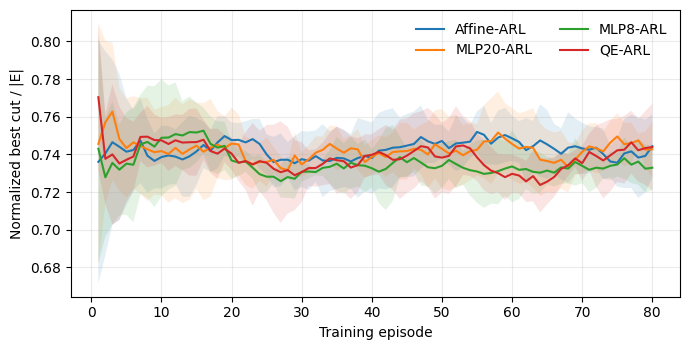

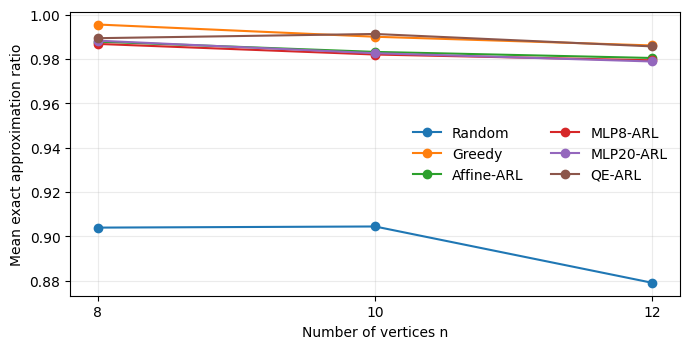

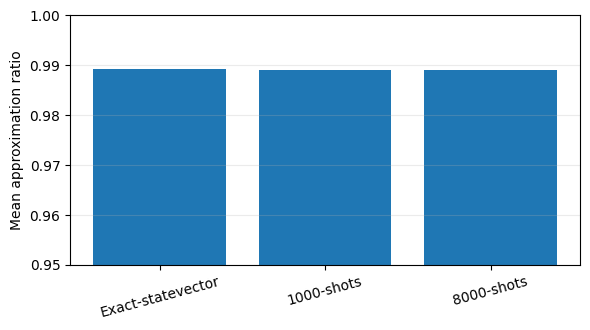

All core sanity checks passed.
Results package: /content/artifacts/QE_ARL_complete_revision_results.zip
When Run all finishes, send me the ZIP above (or the artifact CSVs) and I will update the conference paper from the actual outputs.


In [10]:
# Training curves
h=training_history.copy()
h['smooth']=h.groupby(['seed','method'])['normalized_best'].transform(lambda s:s.rolling(10,min_periods=1).mean())
fig,ax=plt.subplots(figsize=(7,3.6))
for method,g in h.groupby('method'):
    pv=g.pivot(index='episode',columns='seed',values='smooth'); mean=pv.mean(axis=1); std=pv.std(axis=1).fillna(0)
    ax.plot(mean.index,mean,label=method); ax.fill_between(mean.index,mean-std,mean+std,alpha=.12)
ax.set_xlabel('Training episode'); ax.set_ylabel('Normalized best cut / |E|'); ax.grid(True,alpha=.25); ax.legend(frameon=False,ncol=2)
fig.tight_layout(); fig.savefig(OUT/'training_curves_revised.png',dpi=220,bbox_inches='tight'); plt.show()

# Main exact benchmark by n
means=results.groupby(['n','method']).approx_ratio.mean().unstack()
fig,ax=plt.subplots(figsize=(7,3.6))
for method in ['Random','Greedy','Affine-ARL','MLP8-ARL','MLP20-ARL','QE-ARL']:
    ax.plot(means.index,means[method],marker='o',label=method)
ax.set_xlabel('Number of vertices n'); ax.set_ylabel('Mean exact approximation ratio'); ax.set_xticks(means.index); ax.grid(True,alpha=.25); ax.legend(frameon=False,ncol=2)
fig.tight_layout(); fig.savefig(OUT/'exact_ratio_by_size_revised.png',dpi=220,bbox_inches='tight'); plt.show()

# Shot robustness
fig,ax=plt.subplots(figsize=(6,3.4))
ss=shot_summary.set_index('mode').loc[['Exact-statevector','1000-shots','8000-shots']]
ax.bar(np.arange(len(ss)),ss.mean_ratio.to_numpy())
ax.set_xticks(np.arange(len(ss)),ss.index,rotation=15); ax.set_ylabel('Mean approximation ratio'); ax.set_ylim(min(.95,ss.mean_ratio.min()-.01),1.0); ax.grid(True,axis='y',alpha=.25)
fig.tight_layout(); fig.savefig(OUT/'shot_noise_robustness.png',dpi=220,bbox_inches='tight'); plt.show()

# Export all result objects.
exports={
    'training_history_5seeds.csv':training_history,
    'main_results_exact_72graphs.csv':results,
    'main_summary_exact_72graphs.csv':main_summary,
    'paired_QE_differences.csv':paired,
    'shot_noise_results.csv':shot_results,
    'shot_noise_summary.csv':shot_summary,
    'shot_noise_paired.csv':shot_paired,
    'spsa_parameter_shift_validation.csv':grad_validation,
    'large_scale_unweighted.csv':large_unweighted,
    'large_scale_weighted.csv':large_weighted,
    'qaoa_p2_full72.csv':qaoa_results,
    'gset_sources_sha256.csv':gset_sources,
    'gset_results.csv':gset_results,
    'gset_summary.csv':gset_summary,
}
for filename,df in exports.items():
    df.to_csv(OUT/filename,index=False)

# Run manifest helps us audit exactly which experiment configuration produced the CSVs.
manifest={
    'train_seeds':TRAIN_SEEDS,
    'training_episodes':TRAIN_EPISODES,
    'learning_rate':LEARNING_RATE,
    'main_test_graph_seed':TEST_GRAPH_SEED,
    'main_sizes':N_VALUES,
    'main_densities':P_VALUES,
    'instances_per_setting':INSTANCES_PER_SETTING,
    'eval_repeats':EVAL_REPEATS,
    'episode_horizon':MAX_STEPS,
    'shot_counts':[1000,8000],
    'scale_sizes':[16,20,24],
    'scale_reference':'300-restart, 3-kick multi-start iterated steepest-ascent feasible lower bound',
    'weighted_ER_weights':'positive integers 1..10',
    'qaoa_p':2,
    'qaoa_restarts':3,
    'qaoa_maxiter':80,
    'qaoa_sample_shots':1000,
    'gset_instances':list(GSET_META),
    'gset_steps':GSET_STEPS,
    'vqc_parameters':8,
    'mlp8_parameters':8,
    'mlp20_parameters':20,
    'affine_parameters':20,
}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2))

# Sanity checks
assert len(TRAIN_SEEDS)>3
assert len(graphs)==72
assert results.approx_ratio.between(0,1).all()
assert np.all(results.cut<=results.optimum)
assert {'MLP8-ARL','MLP20-ARL','QE-ARL','Affine-ARL'}.issubset(results.method.unique())
assert set(shot_results['mode'])=={'Exact-statevector','1000-shots','8000-shots'}
assert set(qaoa_results.qaoa_p)=={2} and len(qaoa_results)==72
assert set(GSET_META)==set(gset_sources.instance)
assert any(gset_sources.weights.eq('±1'))
print('All core sanity checks passed.')

# Package everything produced by this run.
zip_path=OUT/'QE_ARL_complete_revision_results.zip'
with zipfile.ZipFile(zip_path,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.iterdir()):
        if p.is_file() and p.name!=zip_path.name:
            z.write(p,arcname=p.name)
print('Results package:',zip_path.resolve())
print('When Run all finishes, send me the ZIP above (or the artifact CSVs) and I will update the conference paper from the actual outputs.')